# 🎵 Idle 상태 컬럼 분류 모델 (완전 버전)

이 노트북은 Idle 상태 데이터를 분석하고 분류 모델을 구축합니다.

## 📋 작업 순서
1. **전체 데이터 로드**
2. **Idle 상태 데이터만 필터링**
3. **원본 데이터 시각화 및 통계**: Waveform과 Mel Spectrogram 분석
4. **멜 스펙트로그램 특징 분석**: 특정 주파수 찾기 및 시각화
5. **Waveform 특징 추출 및 어텐션**: 중요 영역 강조
6. **데이터 증강**: 클래스 불균형 해소
7. **모델 학습**: Waveform CNN + Masked Mel Spectrogram CNN 앙상블
8. **학습 및 평가**

In [139]:
# ============================================================
# 필수 라이브러리 임포트
# ============================================================

import os
import sys
sys.path.insert(0, '..')

import warnings
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm import tqdm
from collections import Counter, defaultdict
from typing import Optional, Tuple, List, Dict
from dataclasses import dataclass
from enum import Enum

import librosa
import librosa.display
from scipy import signal
from scipy.stats import zscore

# PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

# 머신러닝
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# 공통 유틸리티
from utils import setup_plotting, get_data_dir, get_state_mapping, get_state_names

# 프로젝트 모듈
from app.ml.features.extractor import AudioFeatureExtractor, AudioConfig
from app.ml.features.augmentation import AudioAugmentor, AugmentationConfig

warnings.filterwarnings('ignore')

# 시각화 설정
setup_plotting()

# 디바이스 설정
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ 라이브러리 로드 완료!")
print(f"🖥️ Device: {device}")

✅ 라이브러리 로드 완료!
🖥️ Device: cpu


---
## 1. 전체 데이터 로드

In [140]:
# ============================================================
# 전체 데이터 로드
# ============================================================

data_dir = get_data_dir()

# 전체 오디오 파일 수집
all_files_all_states = []
all_labels_all_states = []
all_states_all = []

print("📂 전체 데이터 로드 중...")

for state_dir in sorted(data_dir.iterdir()):
    if not state_dir.is_dir() or state_dir.name == 'augmented':
        continue
    
    state_name = state_dir.name
    
    for problem_dir in sorted(state_dir.iterdir()):
        if not problem_dir.is_dir():
            continue
        
        problem_name = problem_dir.name
        
        # Combined 클래스 제외
        if 'combined' in problem_name.lower():
            continue
        
        # 하위 폴더 확인 (combined 제외)
        has_combined = False
        try:
            for sub_dir in problem_dir.iterdir():
                if sub_dir.is_dir() and 'combined' in sub_dir.name.lower():
                    has_combined = True
                    break
        except:
            pass
        
        if has_combined:
            continue
        
        # WAV 파일 수집
        wav_files = list(problem_dir.glob('*.wav'))
        
        for wav_file in wav_files:
            all_files_all_states.append(wav_file)
            all_labels_all_states.append(problem_name)
            all_states_all.append(state_name)
        
        # 하위 폴더의 WAV 파일 수집 (combined 제외)
        try:
            for sub_dir in problem_dir.iterdir():
                if sub_dir.is_dir() and 'combined' not in sub_dir.name.lower():
                    sub_wav_files = list(sub_dir.glob('*.wav'))
                    for wav_file in sub_wav_files:
                        all_files_all_states.append(wav_file)
                        all_labels_all_states.append(f"{problem_name}/{sub_dir.name}")
                        all_states_all.append(state_name)
        except:
            pass

print(f"\n📊 전체 데이터: {len(all_files_all_states)}개")
print(f"📊 상태별 분포:")
state_counts = Counter(all_states_all)
for state, count in sorted(state_counts.items()):
    print(f"  {state}: {count}개")

📂 전체 데이터 로드 중...

📊 전체 데이터: 949개
📊 상태별 분포:
  braking state: 153개
  idle state: 616개
  startup state: 180개


---
## 2. Idle 상태 데이터만 필터링

In [141]:
# ============================================================
# Idle 상태 데이터만 필터링
# ============================================================

all_files = []
all_labels = []

for file_path, label, state in zip(all_files_all_states, all_labels_all_states, all_states_all):
    if 'idle' in state.lower():
        all_files.append(file_path)
        all_labels.append(label)

print(f"\n✅ Idle 상태 데이터 필터링 완료!")
print(f"📊 Idle 상태 데이터: {len(all_files)}개")
if len(all_files) > 0:
    print(f"📊 컬럼별 분포:")
    column_counts = Counter(all_labels)
    for column, count in sorted(column_counts.items()):
        print(f"  {column}: {count}개")
else:
    print("⚠️ 데이터가 없습니다. 디렉토리 경로를 확인해주세요.")


✅ Idle 상태 데이터 필터링 완료!
📊 Idle 상태 데이터: 616개
📊 컬럼별 분포:
  low_oil: 107개
  normal_engine_idle: 264개
  power_steering: 129개
  serpentine_belt: 116개


---
## 3. 원본 데이터 시각화 및 통계 (Waveform & Mel Spectrogram)

In [142]:
# ============================================================
# 오디오 특징 추출 설정
# ============================================================

print("📊 실제 오디오 길이 확인 중...")
durations = []
for file_path in tqdm(all_files[:100] if len(all_files) > 100 else all_files, desc="길이 확인"):
    try:
        y, sr = librosa.load(str(file_path), sr=None)
        duration = len(y) / sr
        durations.append(duration)
    except:
        continue

if len(durations) > 0:
    durations = np.array(durations)
    print(f"\n📈 오디오 길이 통계:")
    print(f"  • 평균 길이: {np.mean(durations):.2f}초")
    print(f"  • 최소 길이: {np.min(durations):.2f}초")
    print(f"  • 최대 길이: {np.max(durations):.2f}초")
    print(f"  • 표준편차: {np.std(durations):.2f}초")
    
    max_duration = max(np.max(durations) * 1.2, 2.0)
    recommended_duration = min(max_duration, 2.0)
    print(f"\n💡 권장 duration: {recommended_duration:.1f}초")
else:
    recommended_duration = 2.0
    print(f"⚠️ 오디오 길이를 확인할 수 없어 기본값 사용: {recommended_duration}초")

audio_config = AudioConfig(
    sample_rate=22050,
    duration=recommended_duration,
    n_mels=128,
    n_fft=2048,
    hop_length=512
)

feature_extractor = AudioFeatureExtractor(audio_config)

print(f"\n🔄 Waveform 및 Mel Spectrogram 추출 중... (duration: {audio_config.duration}초)")

📊 실제 오디오 길이 확인 중...


길이 확인: 100%|██████████| 100/100 [00:00<00:00, 1492.59it/s]


📈 오디오 길이 통계:
  • 평균 길이: 1.50초
  • 최소 길이: 1.50초
  • 최대 길이: 1.50초
  • 표준편차: 0.00초

💡 권장 duration: 2.0초

🔄 Waveform 및 Mel Spectrogram 추출 중... (duration: 2.0초)


In [143]:
# ============================================================
# Waveform 및 Mel Spectrogram 추출 (원본 데이터)
# ============================================================

X_waveform = []
X_mel = []
y_columns = []
actual_durations = []

for file_path, label in tqdm(zip(all_files, all_labels), total=len(all_files)):
    try:
        y, sr = librosa.load(str(file_path), sr=audio_config.sample_rate)
        
        actual_duration = len(y) / sr
        actual_durations.append(actual_duration)
        
        target_length = int(audio_config.sample_rate * audio_config.duration)
        if len(y) < target_length:
            y_padded = np.pad(y, (0, target_length - len(y)), mode='constant')
        elif len(y) > target_length:
            y_padded = y[:target_length]
        else:
            y_padded = y
        
        X_waveform.append(y_padded)
        
        mel_spec = feature_extractor.extract_mel_spectrogram(y, int(sr), to_db=False)
        mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)
        X_mel.append(mel_spec_db)
        
        y_columns.append(label)
        
    except Exception as e:
        print(f"⚠️ 오류 발생: {file_path} - {e}")
        continue

X_waveform = np.array(X_waveform)
X_mel = np.array(X_mel)
y_columns = np.array(y_columns)
actual_durations = np.array(actual_durations)

print(f"\n✅ 추출 완료!")
print(f"  Waveform shape: {X_waveform.shape}")
print(f"  Mel Spectrogram shape: {X_mel.shape}")
print(f"  컬럼 레이블 shape: {y_columns.shape}")
print(f"  실제 오디오 평균 길이: {np.mean(actual_durations):.2f}초")

# 원본 데이터 저장 (마스크 생성용)
X_waveform_original = X_waveform.copy()
X_mel_original = X_mel.copy()
y_columns_original = y_columns.copy()
print(f"  📌 원본 데이터 저장 완료 (마스크 생성용)")

100%|██████████| 616/616 [00:04<00:00, 126.58it/s]



✅ 추출 완료!
  Waveform shape: (616, 44100)
  Mel Spectrogram shape: (616, 128, 65)
  컬럼 레이블 shape: (616,)
  실제 오디오 평균 길이: 1.50초
  📌 원본 데이터 저장 완료 (마스크 생성용)



📊 Waveform 통계:
  평균 진폭: 0.057054
  최대 진폭: 0.961255
  표준편차: 0.101126

📊 Mel Spectrogram 통계:
  평균 값: -30.22 dB
  최소 값: -80.00 dB
  최대 값: 0.00 dB
  표준편차: 13.08 dB


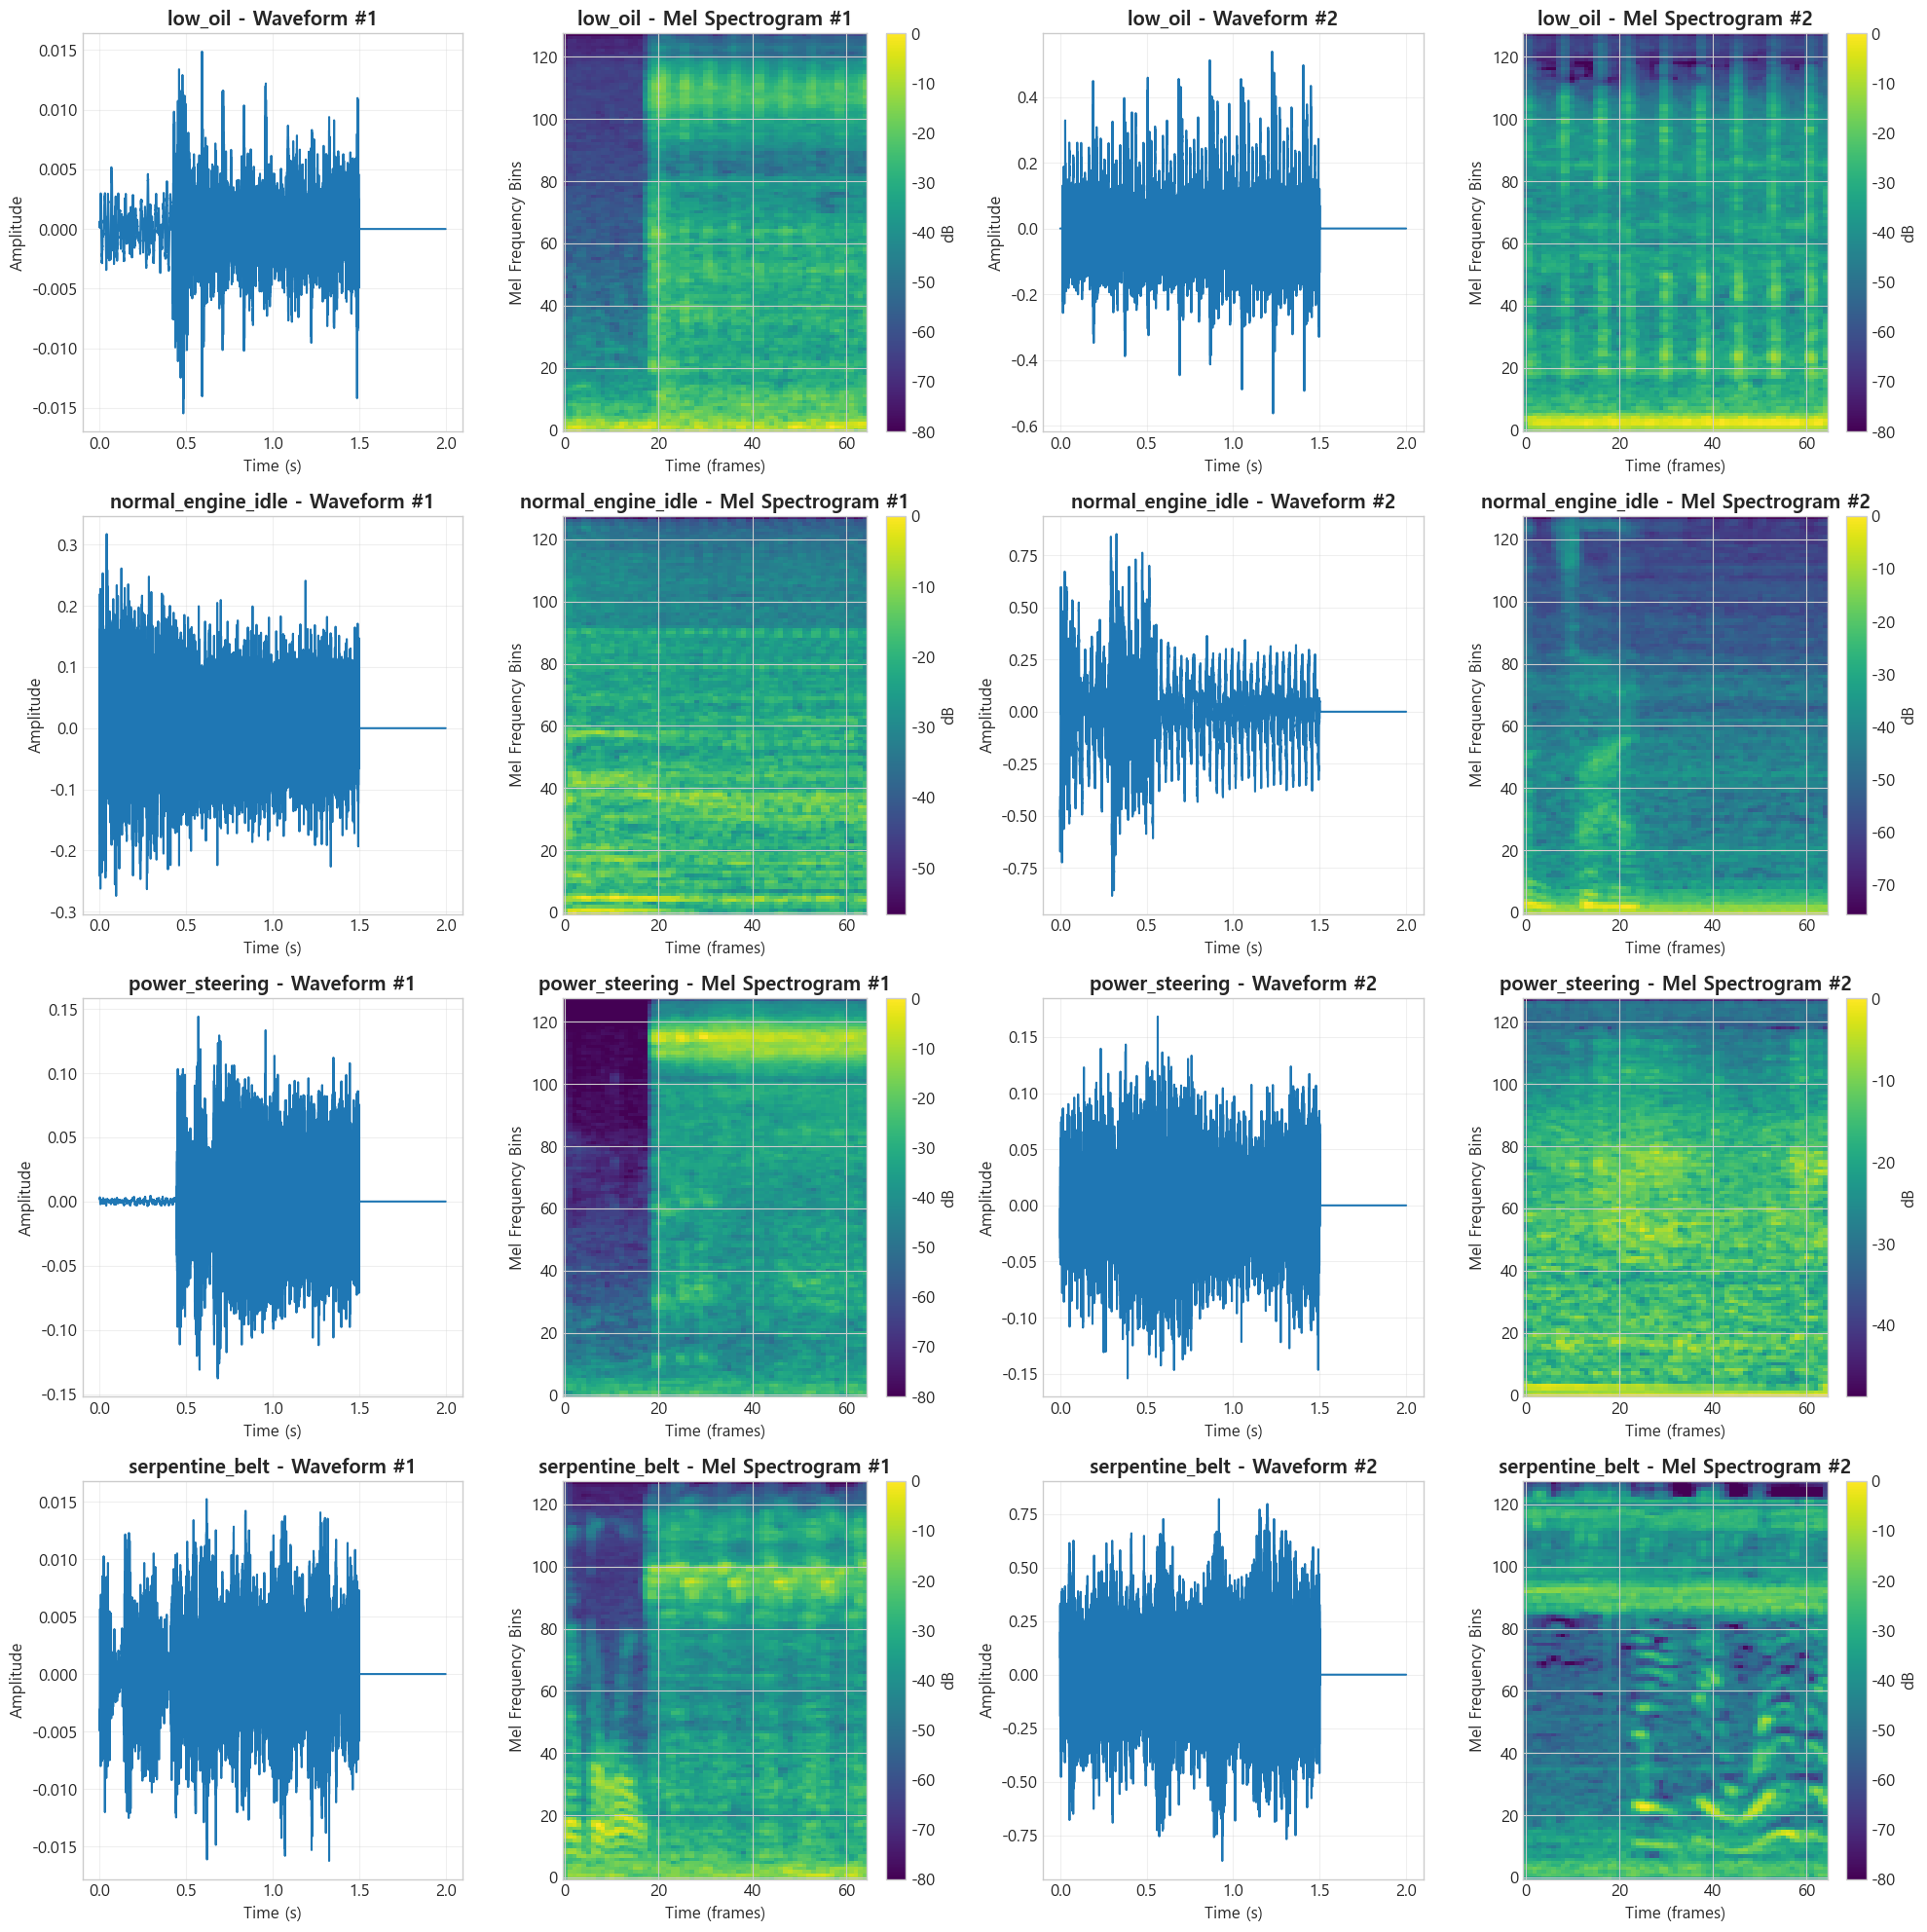


✅ Waveform 및 Mel Spectrogram 시각화 완료!


In [144]:
# ============================================================
# Waveform 및 Mel Spectrogram 통계 및 시각화
# ============================================================

# Waveform 통계
print("\n📊 Waveform 통계:")
print(f"  평균 진폭: {np.mean(np.abs(X_waveform)):.6f}")
print(f"  최대 진폭: {np.max(np.abs(X_waveform)):.6f}")
print(f"  표준편차: {np.std(X_waveform):.6f}")

# Mel Spectrogram 통계
print("\n📊 Mel Spectrogram 통계:")
print(f"  평균 값: {np.mean(X_mel):.2f} dB")
print(f"  최소 값: {np.min(X_mel):.2f} dB")
print(f"  최대 값: {np.max(X_mel):.2f} dB")
print(f"  표준편차: {np.std(X_mel):.2f} dB")

# 컬럼별 샘플 시각화
unique_columns = sorted(np.unique(y_columns_original))
num_samples_per_class = 2

fig, axes = plt.subplots(len(unique_columns), 4, figsize=(20, 5 * len(unique_columns)))
if len(unique_columns) == 1:
    axes = axes.reshape(1, -1)

for row_idx, column in enumerate(unique_columns):
    column_indices = np.where(y_columns_original == column)[0]
    
    for col_idx in range(num_samples_per_class):
        if col_idx < len(column_indices):
            sample_idx = column_indices[col_idx]
            
            # Waveform 시각화
            time_axis = np.linspace(0, audio_config.duration, len(X_waveform_original[sample_idx]))
            axes[row_idx, col_idx * 2].plot(time_axis, X_waveform_original[sample_idx])
            axes[row_idx, col_idx * 2].set_title(f'{column} - Waveform #{col_idx+1}', fontweight='bold')
            axes[row_idx, col_idx * 2].set_xlabel('Time (s)')
            axes[row_idx, col_idx * 2].set_ylabel('Amplitude')
            axes[row_idx, col_idx * 2].grid(True, alpha=0.3)
            
            # Mel Spectrogram 시각화
            mel_spec_db = X_mel_original[sample_idx]
            im = axes[row_idx, col_idx * 2 + 1].imshow(mel_spec_db, aspect='auto', origin='lower', cmap='viridis')
            axes[row_idx, col_idx * 2 + 1].set_title(f'{column} - Mel Spectrogram #{col_idx+1}', fontweight='bold')
            axes[row_idx, col_idx * 2 + 1].set_xlabel('Time (frames)')
            axes[row_idx, col_idx * 2 + 1].set_ylabel('Mel Frequency Bins')
            plt.colorbar(im, ax=axes[row_idx, col_idx * 2 + 1], label='dB')

plt.tight_layout()
plt.show()

print("\n✅ Waveform 및 Mel Spectrogram 시각화 완료!")

---
## 4. 멜 스펙트로그램 특징 분석 및 특정 주파수 찾기

In [145]:
# ============================================================
# 컬럼별 평균 Mel Spectrogram 계산
# ============================================================

unique_columns_original = sorted(np.unique(y_columns_original))

column_means = {}
for column in unique_columns_original:
    column_indices = np.where(y_columns_original == column)[0]
    if len(column_indices) > 0:
        column_means[column] = np.mean(X_mel_original[column_indices], axis=0)

print(f"✅ 컬럼별 평균 Mel Spectrogram 계산 완료! ({len(column_means)}개 컬럼)")

✅ 컬럼별 평균 Mel Spectrogram 계산 완료! (4개 컬럼)


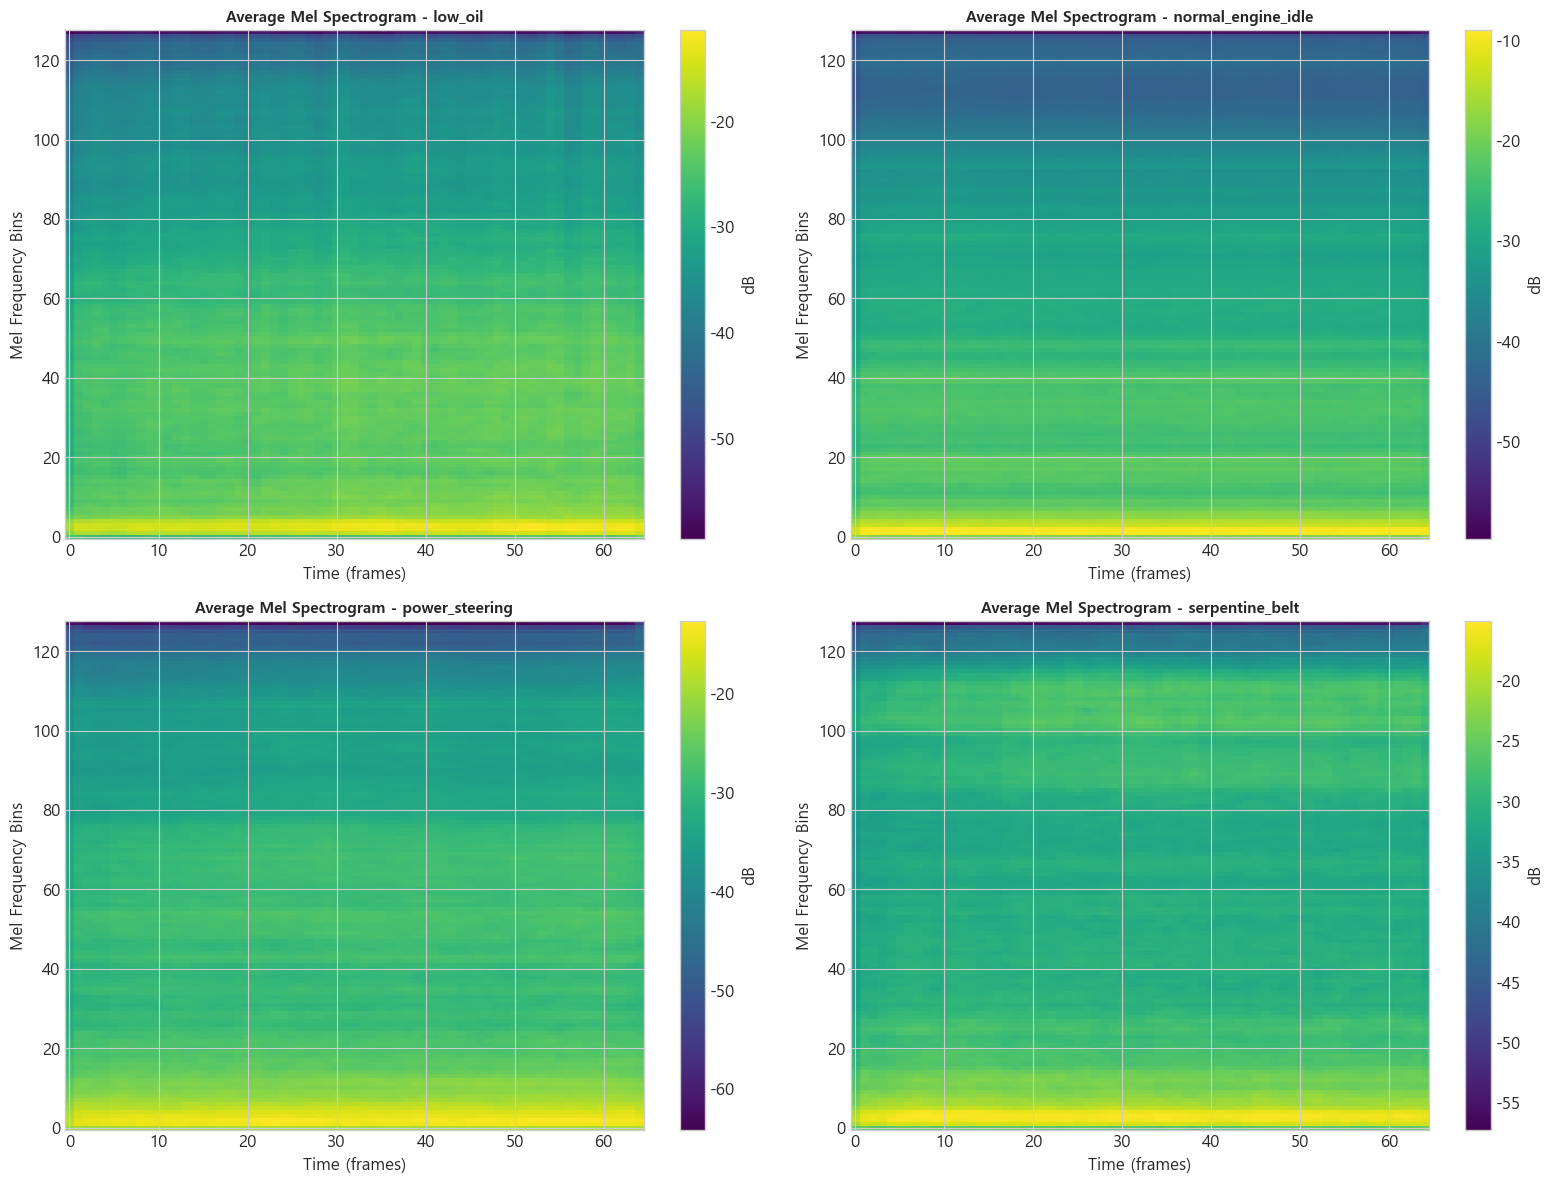

✅ 컬럼별 평균 Mel Spectrogram 시각화 완료!


In [146]:
# ============================================================
# 컬럼별 평균 Mel Spectrogram 시각화
# ============================================================

columns_to_compare = list(column_means.keys())[:4]  # 처음 4개 컬럼만

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for idx, column in enumerate(columns_to_compare):
    if column in column_means:
        mel_mean_db = column_means[column]
        im = axes[idx].imshow(mel_mean_db, aspect='auto', origin='lower', cmap='viridis')
        axes[idx].set_title(f'Average Mel Spectrogram - {column}', fontsize=11, fontweight='bold')
        axes[idx].set_xlabel('Time (frames)')
        axes[idx].set_ylabel('Mel Frequency Bins')
        plt.colorbar(im, ax=axes[idx], label='dB')

plt.tight_layout()
plt.show()

print("✅ 컬럼별 평균 Mel Spectrogram 시각화 완료!")

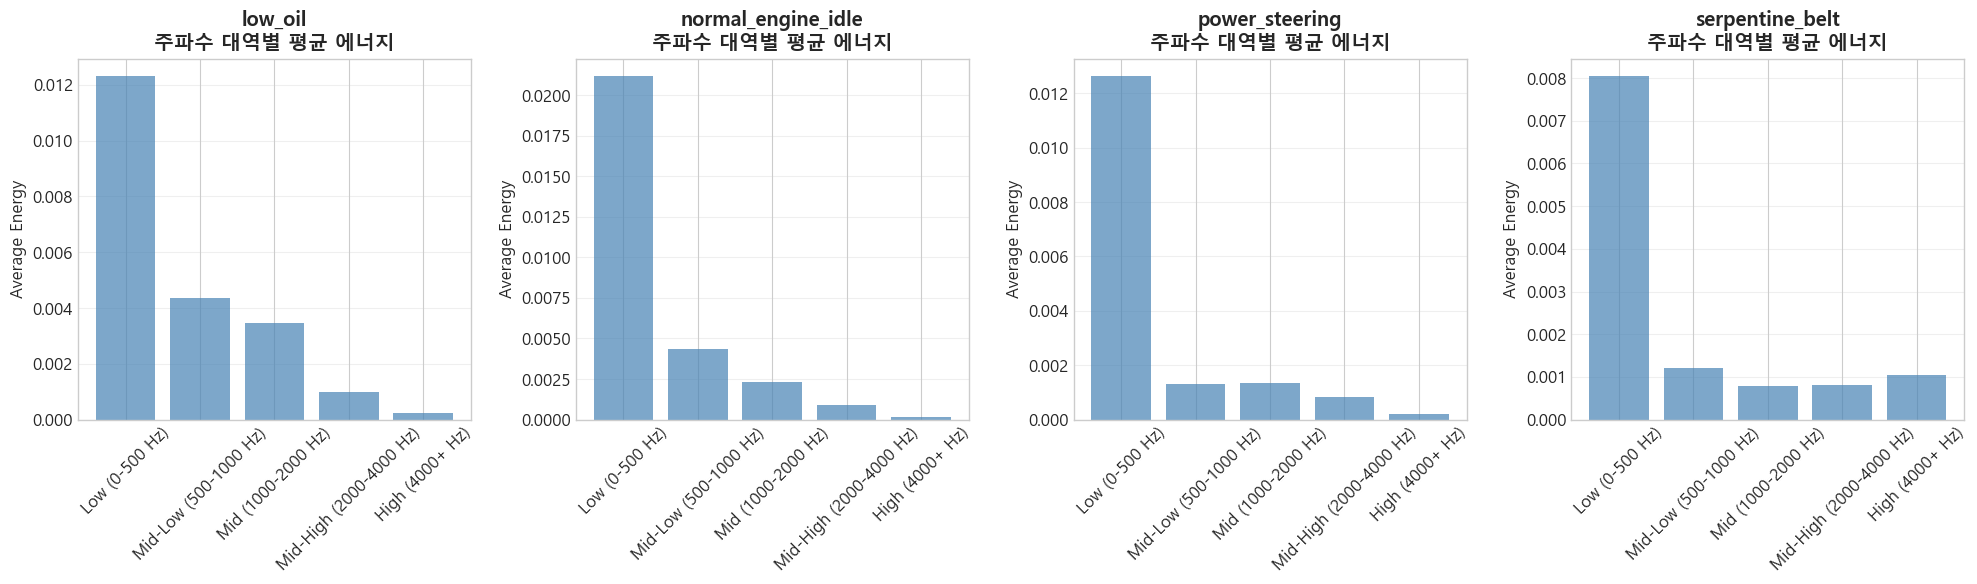

✅ 주파수 대역별 에너지 분석 완료!


In [147]:
# ============================================================
# 특정 주파수 대역 분석 및 시각화
# ============================================================

# Mel 주파수를 실제 주파수로 변환
mel_freqs = librosa.mel_frequencies(n_mels=audio_config.n_mels, fmin=0, fmax=audio_config.sample_rate // 2)

# 각 컬럼별로 주파수 대역별 평균 에너지 계산
frequency_bands = {
    'Low (0-500 Hz)': (0, 500),
    'Mid-Low (500-1000 Hz)': (500, 1000),
    'Mid (1000-2000 Hz)': (1000, 2000),
    'Mid-High (2000-4000 Hz)': (2000, 4000),
    'High (4000+ Hz)': (4000, audio_config.sample_rate // 2)
}

column_freq_energy = {}
for column in unique_columns_original:
    if column in column_means:
        mel_mean = column_means[column]
        # dB를 power로 변환하여 평균 계산
        mel_power = librosa.db_to_power(mel_mean)
        
        freq_energy = {}
        for band_name, (f_min, f_max) in frequency_bands.items():
            # 해당 주파수 대역에 해당하는 mel bin 찾기
            band_indices = np.where((mel_freqs >= f_min) & (mel_freqs <= f_max))[0]
            if len(band_indices) > 0:
                freq_energy[band_name] = np.mean(mel_power[band_indices, :])
            else:
                freq_energy[band_name] = 0.0
        
        column_freq_energy[column] = freq_energy

# 주파수 대역별 에너지 시각화
fig, axes = plt.subplots(1, len(unique_columns_original), figsize=(5 * len(unique_columns_original), 6))
if len(unique_columns_original) == 1:
    axes = [axes]

for idx, column in enumerate(unique_columns_original):
    if column in column_freq_energy:
        bands = list(column_freq_energy[column].keys())
        energies = list(column_freq_energy[column].values())
        
        axes[idx].bar(bands, energies, color='steelblue', alpha=0.7)
        axes[idx].set_title(f'{column}\n주파수 대역별 평균 에너지', fontweight='bold')
        axes[idx].set_ylabel('Average Energy')
        axes[idx].tick_params(axis='x', rotation=45)
        axes[idx].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("✅ 주파수 대역별 에너지 분석 완료!")

✅ 중요 영역 마스크 생성 완료!
  마스크 shape: (128, 65)
  마스크 범위: [0.000, 1.000]
  마스크 평균값: 0.356


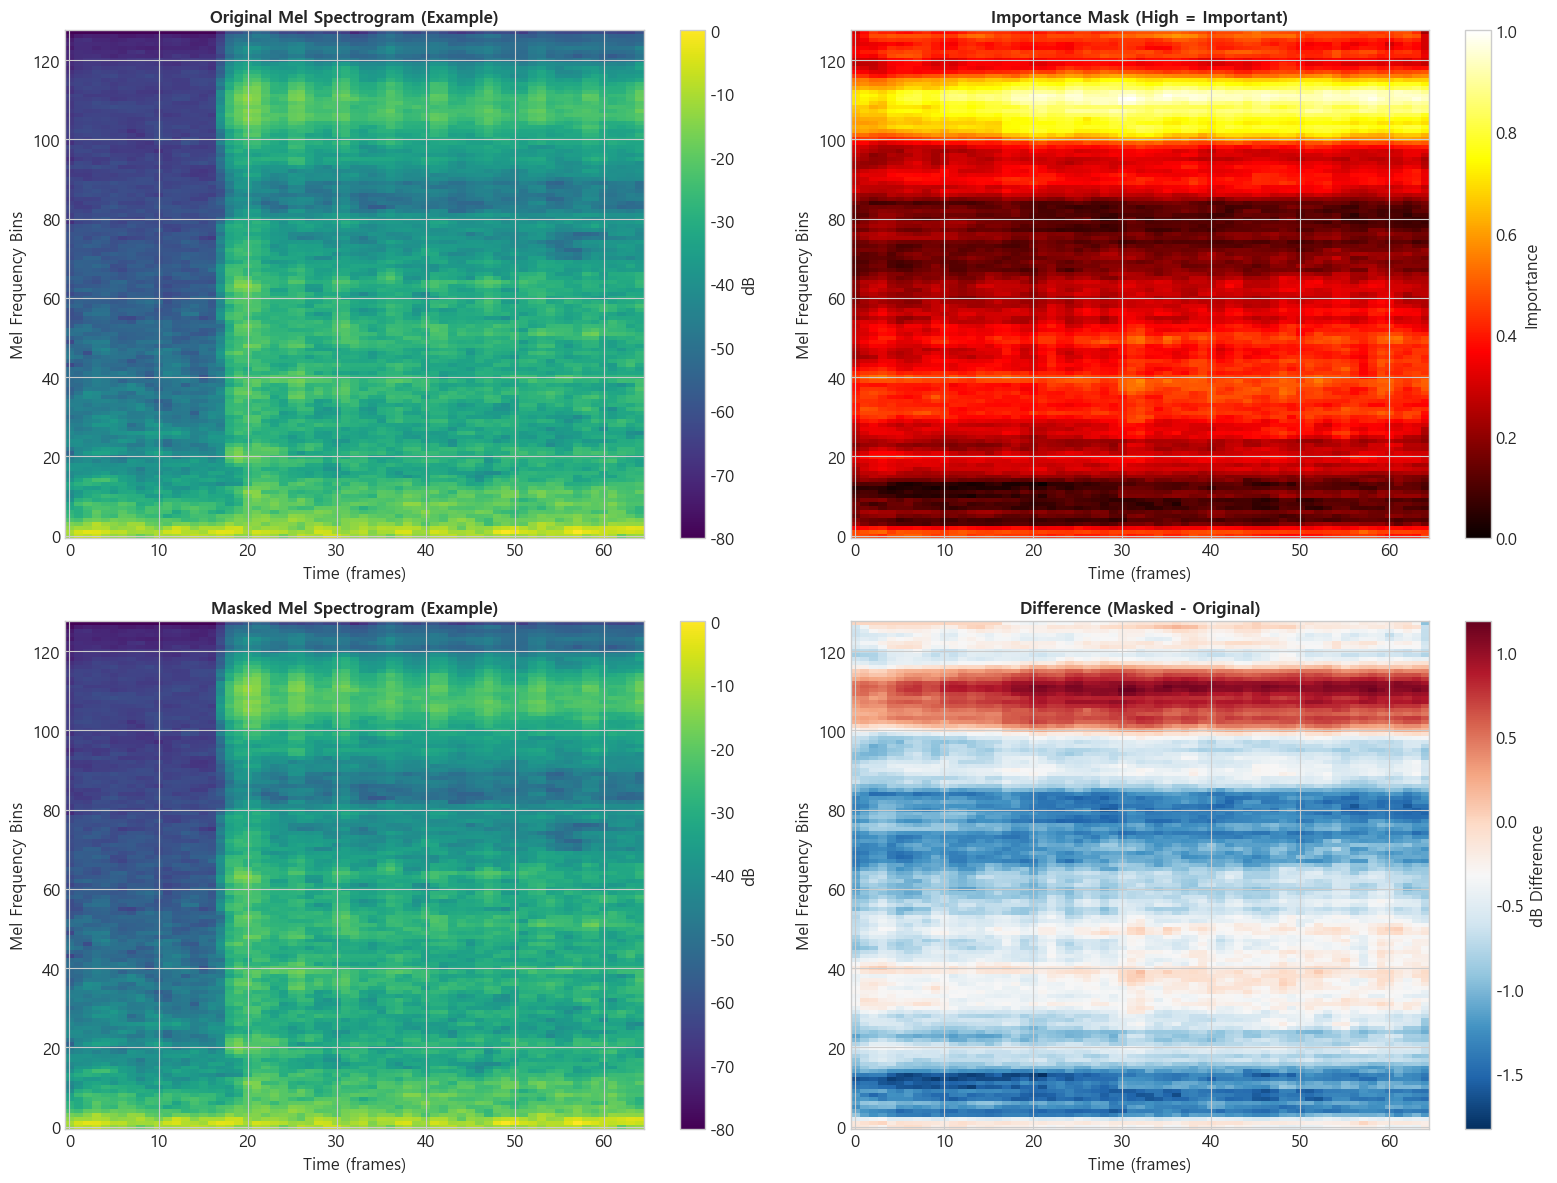

✅ 마스크 시각화 완료!


In [148]:
# ============================================================
# 중요 영역 마스크 생성 (컬럼 간 차이 기반)
# ============================================================

importance_mask = np.zeros_like(X_mel_original[0])

columns_list = list(column_means.keys())
for i in range(len(columns_list)):
    for j in range(i + 1, len(columns_list)):
        diff = np.abs(column_means[columns_list[i]] - column_means[columns_list[j]])
        importance_mask = np.maximum(importance_mask, diff)

if importance_mask.max() > importance_mask.min():
    importance_mask = (importance_mask - importance_mask.min()) / (importance_mask.max() - importance_mask.min())
else:
    importance_mask = np.ones_like(importance_mask) * 0.5

importance_mask_tensor = torch.FloatTensor(importance_mask).unsqueeze(0).to(device)

print(f"✅ 중요 영역 마스크 생성 완료!")
print(f"  마스크 shape: {importance_mask.shape}")
print(f"  마스크 범위: [{importance_mask.min():.3f}, {importance_mask.max():.3f}]")
print(f"  마스크 평균값: {importance_mask.mean():.3f}")

# 마스크 시각화
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. 원본 Mel Spectrogram (예시)
sample_idx = 0
mel_spec_db = X_mel_original[sample_idx]
im1 = axes[0, 0].imshow(mel_spec_db, aspect='auto', origin='lower', cmap='viridis')
axes[0, 0].set_title('Original Mel Spectrogram (Example)', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Time (frames)')
axes[0, 0].set_ylabel('Mel Frequency Bins')
plt.colorbar(im1, ax=axes[0, 0], label='dB')

# 2. 중요 영역 마스크
im2 = axes[0, 1].imshow(importance_mask, aspect='auto', origin='lower', cmap='hot')
axes[0, 1].set_title('Importance Mask (High = Important)', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Time (frames)')
axes[0, 1].set_ylabel('Mel Frequency Bins')
plt.colorbar(im2, ax=axes[0, 1], label='Importance')

# 3. 마스크 적용된 Mel Spectrogram
mel_spec_power = librosa.db_to_power(mel_spec_db)
masked_mel_power = mel_spec_power * (1 + importance_mask)
masked_mel_db = librosa.power_to_db(masked_mel_power, ref=np.max)
im3 = axes[1, 0].imshow(masked_mel_db, aspect='auto', origin='lower', cmap='viridis')
axes[1, 0].set_title('Masked Mel Spectrogram (Example)', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Time (frames)')
axes[1, 0].set_ylabel('Mel Frequency Bins')
plt.colorbar(im3, ax=axes[1, 0], label='dB')

# 4. 차이 시각화
diff = masked_mel_db - mel_spec_db
im4 = axes[1, 1].imshow(diff, aspect='auto', origin='lower', cmap='RdBu_r')
axes[1, 1].set_title('Difference (Masked - Original)', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Time (frames)')
axes[1, 1].set_ylabel('Mel Frequency Bins')
plt.colorbar(im4, ax=axes[1, 1], label='dB Difference')

plt.tight_layout()
plt.show()

print("✅ 마스크 시각화 완료!")

---
## 5. Waveform 특징 추출 및 어텐션

In [149]:
# ============================================================
# Waveform 특징 추출 (에너지, 제로 크로싱, 스펙트럴 특징)
# ============================================================

def extract_waveform_features(waveform, sr=22050):
    """Waveform에서 특징 추출"""
    features = {}
    
    # 1. RMS 에너지
    features['rms'] = librosa.feature.rms(y=waveform)[0]
    
    # 2. Zero Crossing Rate
    features['zcr'] = librosa.feature.zero_crossing_rate(waveform)[0]
    
    # 3. 스펙트럴 센트로이드
    features['spectral_centroid'] = librosa.feature.spectral_centroid(y=waveform, sr=sr)[0]
    
    # 4. 스펙트럴 롤오프
    features['spectral_rolloff'] = librosa.feature.spectral_rolloff(y=waveform, sr=sr)[0]
    
    # 5. 스펙트럴 대역폭
    features['spectral_bandwidth'] = librosa.feature.spectral_bandwidth(y=waveform, sr=sr)[0]
    
    return features

# 샘플에 대해 특징 추출
sample_features = extract_waveform_features(X_waveform_original[0], audio_config.sample_rate)

print("✅ Waveform 특징 추출 함수 정의 완료!")
print(f"\n📊 샘플 특징:")
for feat_name, feat_value in sample_features.items():
    print(f"  {feat_name}: shape={feat_value.shape}, mean={np.mean(feat_value):.4f}")

✅ Waveform 특징 추출 함수 정의 완료!

📊 샘플 특징:
  rms: shape=(87,), mean=0.0017
  zcr: shape=(87,), mean=0.1554
  spectral_centroid: shape=(87,), mean=2466.6009
  spectral_rolloff: shape=(87,), mean=4245.1349
  spectral_bandwidth: shape=(87,), mean=2017.1491


---
## 6. 데이터 증강

In [150]:
# ============================================================
# 데이터 증강 (Data Augmentation)
# ============================================================

print("\n🔄 데이터 증강 시작...")
def apply_spec_augment(mel_spectrogram, config):
    """멜 스펙트로그램에 SpecAugment (Frequency and Time Masking)를 적용"""
    spec = mel_spectrogram.copy()
    num_mels, num_frames = spec.shape

    # 1. Frequency Masking (주파수 축)
    if config.freq_mask_max_bins > 0 and config.freq_mask_count > 0:
        for _ in range(config.freq_mask_count):
            # 마스킹할 주파수 채널의 개수를 랜덤 선택
            f = np.random.randint(0, config.freq_mask_max_bins)
            f0 = np.random.randint(0, num_mels - f)
            # 해당 범위의 값을 멜 스펙트로그램의 최솟값으로 채우기 (블록 처리)
            spec[f0:f0 + f, :] = spec.min()

    # 2. Time Masking (시간 축)
    if config.time_mask_max_frames > 0 and config.time_mask_count > 0:
        for _ in range(config.time_mask_count):
            # 마스킹할 시간 프레임의 개수를 랜덤 선택
            t = np.random.randint(0, config.time_mask_max_frames)
            t0 = np.random.randint(0, num_frames - t)
            # 해당 범위의 값을 멜 스펙트로그램의 최솟값으로 채우기
            spec[:, t0:t0 + t] = spec.min()

    return spec

# SpecAugment 설정을 담을 간단한 Config 클래스 (코드 상단에 정의 필요)
class SpecAugmentConfig:
    def __init__(self, freq_mask_count=1, freq_mask_max_bins=10, time_mask_count=1, time_mask_max_frames=30):
        self.freq_mask_count = freq_mask_count
        self.freq_mask_max_bins = freq_mask_max_bins
        self.time_mask_count = time_mask_count
        self.time_mask_max_frames = time_mask_max_frames

# SpecAugment 설정 초기화 (적절한 하이퍼파라미터 선택)
spec_augment_config = SpecAugmentConfig(
    freq_mask_count=2,       # 2번 마스킹
    freq_mask_max_bins=20,   # 최대 20개 멜 빈 마스킹
    time_mask_count=2,       # 2번 마스킹
    time_mask_max_frames=50  # 최대 50개 프레임 마스킹
)
# 컬럼별 개수 확인
unique_columns = sorted(np.unique(y_columns_original))
column_counts = {}
for column in unique_columns:
    column_counts[column] = np.sum(y_columns_original == column)

print("\n📊 증강 전 컬럼별 개수:")
for column, count in column_counts.items():
    print(f"  {column}: {count}개")

# 모든 클래스를 동일한 개수로 맞추기 (가장 큰 개수의 약 1.2배로 설정)
max_count = max(column_counts.values())
target_count = int(max_count * 1.2)
print(f"\n🎯 목표 개수: 각 클래스당 {target_count}개")

# 증강 설정
augmentation_config = AugmentationConfig(
    time_stretch_rate_min=0.85,
    time_stretch_rate_max=1.15,
    pitch_shift_steps_min=-3,
    pitch_shift_steps_max=3,
    noise_factor_min=0.002,
    noise_factor_max=0.01,
    volume_factor_min=0.7,
    volume_factor_max=1.3,
    time_shift_max=0.15
)
augmentor = AudioAugmentor(config=augmentation_config)

# 증강된 데이터 저장
augmented_waveforms = []
augmented_mels = []
augmented_labels = []

# 각 클래스별로 증강 수행
for column in unique_columns:
    column_indices = np.where(y_columns_original == column)[0]
    current_count = len(column_indices)
    
    if current_count >= target_count:
        print(f"\n  {column}: 이미 충분함 ({current_count}개)")
        continue
    
    needed = target_count - current_count
    print(f"\n  {column}: {current_count}개 → {target_count}개 (증강 필요: {needed}개)")
    
    augmented_count = 0
    
    while augmented_count < needed:
        try:
            # 랜덤하게 원본 샘플 선택
            source_idx = random.choice(column_indices)
            source_file = all_files[source_idx]
            
            # 오디오 로드
            y, sr = librosa.load(str(source_file), sr=audio_config.sample_rate)
            
            # 증강 적용
            y_augmented = augmentor.augment(y, sr)
            
            # 길이 정규화
            target_length = int(audio_config.sample_rate * audio_config.duration)
            if len(y_augmented) < target_length:
                y_augmented = np.pad(y_augmented, (0, target_length - len(y_augmented)), mode='constant')
            elif len(y_augmented) > target_length:
                y_augmented = y_augmented[:target_length]
            
            augmented_waveforms.append(y_augmented)
            
            # Mel Spectrogram 추출
            mel_spec_aug = feature_extractor.extract_mel_spectrogram(y_augmented, int(sr), to_db=False)
            mel_spec_aug_db = librosa.power_to_db(mel_spec_aug, ref=np.max)
            mel_spec_aug_db = apply_spec_augment(mel_spec_aug_db, spec_augment_config)
            
            # 원본 Mel Spectrogram의 shape에 맞추기
            if len(X_mel_original) > 0:
                target_time_frames = X_mel_original[0].shape[1]
                current_time_frames = mel_spec_aug_db.shape[1]
                
                if current_time_frames < target_time_frames:
                    padding = np.zeros((mel_spec_aug_db.shape[0], target_time_frames - current_time_frames))
                    padding.fill(mel_spec_aug_db.min())
                    mel_spec_aug_db = np.concatenate([mel_spec_aug_db, padding], axis=1)
                elif current_time_frames > target_time_frames:
                    mel_spec_aug_db = mel_spec_aug_db[:, :target_time_frames]
            
            augmented_mels.append(mel_spec_aug_db)
            
            # 레이블 추가
            augmented_labels.append(column)
            
            augmented_count += 1
            
        except Exception as e:
            print(f"    ⚠️ 증강 오류: {e}")
            continue

# 증강된 데이터를 원본 데이터에 추가
if len(augmented_waveforms) > 0:
    X_waveform = np.concatenate([X_waveform_original, np.array(augmented_waveforms)], axis=0)
    X_mel = np.concatenate([X_mel_original, np.array(augmented_mels)], axis=0)
    y_columns = np.concatenate([y_columns_original, np.array(augmented_labels)], axis=0)
    
    print(f"\n✅ 데이터 증강 완료!")
    print(f"  증강된 샘플: {len(augmented_waveforms)}개")
    print(f"  총 샘플: {len(X_waveform)}개")
    
    # 증강 후 컬럼별 개수 확인
    print(f"\n📊 증강 후 컬럼별 개수:")
    for column in unique_columns:
        count = np.sum(y_columns == column)
        print(f"  {column}: {count}개")
else:
    print("\n⚠️ 증강된 데이터가 없습니다.")
    X_waveform = X_waveform_original.copy()
    X_mel = X_mel_original.copy()
    y_columns = y_columns_original.copy()


🔄 데이터 증강 시작...

📊 증강 전 컬럼별 개수:
  low_oil: 107개
  normal_engine_idle: 264개
  power_steering: 129개
  serpentine_belt: 116개

🎯 목표 개수: 각 클래스당 316개

  low_oil: 107개 → 316개 (증강 필요: 209개)

  normal_engine_idle: 264개 → 316개 (증강 필요: 52개)

  power_steering: 129개 → 316개 (증강 필요: 187개)

  serpentine_belt: 116개 → 316개 (증강 필요: 200개)

✅ 데이터 증강 완료!
  증강된 샘플: 648개
  총 샘플: 1264개

📊 증강 후 컬럼별 개수:
  low_oil: 316개
  normal_engine_idle: 316개
  power_steering: 316개
  serpentine_belt: 316개


✅ Waveform 어텐션 마스크 생성 완료!
  어텐션 마스크 shape: (1264, 44100)
  평균 어텐션 값: 0.558


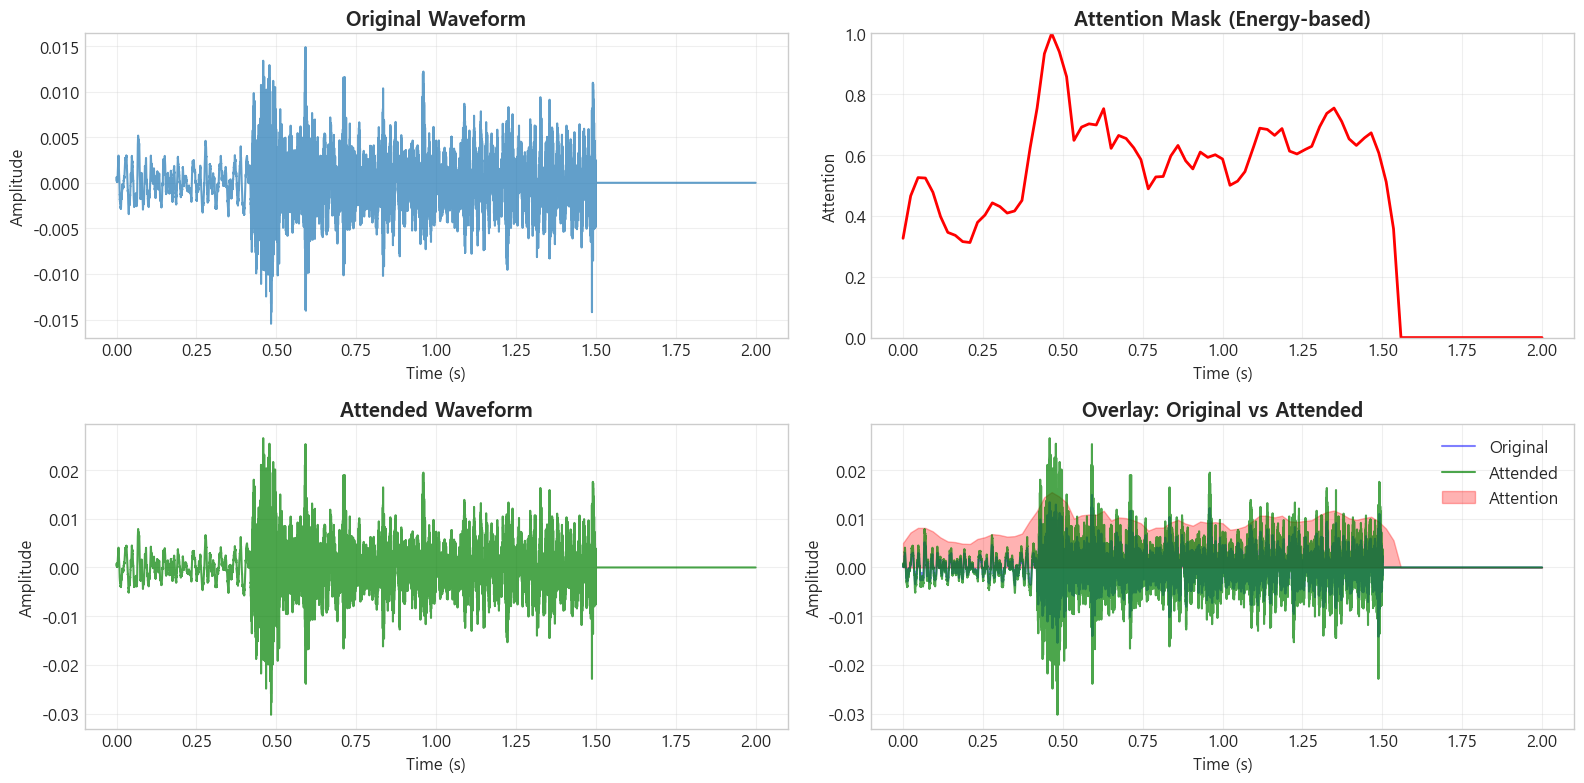

✅ Waveform 어텐션 시각화 완료!


In [151]:
# ============================================================
# Waveform 어텐션 마스크 생성 (에너지 기반)
# ============================================================

# 각 샘플의 RMS 에너지를 계산하여 어텐션 마스크 생성
waveform_attention_masks = []

for waveform in X_waveform:
    rms = librosa.feature.rms(y=waveform)[0]
    # 정규화
    if rms.max() > rms.min():
        attention = (rms - rms.min()) / (rms.max() - rms.min())
    else:
        attention = np.ones_like(rms) * 0.5
    
    # 원본 waveform 길이에 맞추기 위해 보간
    target_length = len(waveform)
    if len(attention) != target_length:
        from scipy.interpolate import interp1d
        x_old = np.linspace(0, 1, len(attention))
        x_new = np.linspace(0, 1, target_length)
        f = interp1d(x_old, attention, kind='linear')
        attention = f(x_new)
    
    waveform_attention_masks.append(attention)

waveform_attention_masks = np.array(waveform_attention_masks)

print(f"✅ Waveform 어텐션 마스크 생성 완료!")
print(f"  어텐션 마스크 shape: {waveform_attention_masks.shape}")
print(f"  평균 어텐션 값: {np.mean(waveform_attention_masks):.3f}")

# 어텐션 마스크 시각화
fig, axes = plt.subplots(2, 2, figsize=(16, 8))

sample_idx = 0
waveform = X_waveform_original[sample_idx]
attention = waveform_attention_masks[sample_idx]
time_axis = np.linspace(0, audio_config.duration, len(waveform))

# 1. 원본 Waveform
axes[0, 0].plot(time_axis, waveform, alpha=0.7)
axes[0, 0].set_title('Original Waveform', fontweight='bold')
axes[0, 0].set_xlabel('Time (s)')
axes[0, 0].set_ylabel('Amplitude')
axes[0, 0].grid(True, alpha=0.3)

# 2. 어텐션 마스크
axes[0, 1].plot(time_axis, attention, color='red', linewidth=2)
axes[0, 1].set_title('Attention Mask (Energy-based)', fontweight='bold')
axes[0, 1].set_xlabel('Time (s)')
axes[0, 1].set_ylabel('Attention')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].set_ylim([0, 1])

# 3. 어텐션 적용된 Waveform
attended_waveform = waveform * (1 + attention)
axes[1, 0].plot(time_axis, attended_waveform, alpha=0.7, color='green')
axes[1, 0].set_title('Attended Waveform', fontweight='bold')
axes[1, 0].set_xlabel('Time (s)')
axes[1, 0].set_ylabel('Amplitude')
axes[1, 0].grid(True, alpha=0.3)

# 4. 오버레이
axes[1, 1].plot(time_axis, waveform, alpha=0.5, label='Original', color='blue')
axes[1, 1].plot(time_axis, attended_waveform, alpha=0.7, label='Attended', color='green')
axes[1, 1].fill_between(time_axis, 0, attention * np.max(np.abs(waveform)), alpha=0.3, color='red', label='Attention')
axes[1, 1].set_title('Overlay: Original vs Attended', fontweight='bold')
axes[1, 1].set_xlabel('Time (s)')
axes[1, 1].set_ylabel('Amplitude')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✅ Waveform 어텐션 시각화 완료!")

---
## 7. 모델 정의 (Waveform CNN + Masked Mel Spectrogram CNN)

In [152]:
# ============================================================
# Waveform 1D CNN 모델
# ============================================================

class WaveformCNN1D(nn.Module):
    def __init__(self, num_classes: int, input_length: int = 110250, base_channels: int = 48, dropout: float = 0.5):
        super().__init__()
        self.num_classes = num_classes
        
        self.conv1 = nn.Sequential(
            nn.Conv1d(1, base_channels, kernel_size=7, stride=2, padding=3),
            nn.BatchNorm1d(base_channels),
            nn.ReLU(inplace=True),
            nn.MaxPool1d(kernel_size=2, stride=2),
            nn.Dropout(dropout / 2)
        )
        
        self.conv2 = nn.Sequential(
            nn.Conv1d(base_channels, base_channels * 2, kernel_size=5, stride=2, padding=2),
            nn.BatchNorm1d(base_channels * 2),
            nn.ReLU(inplace=True),
            nn.MaxPool1d(kernel_size=2, stride=2),
            nn.Dropout(dropout / 2)
        )
        
        self.conv3 = nn.Sequential(
            nn.Conv1d(base_channels * 2, base_channels * 4, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm1d(base_channels * 4),
            nn.ReLU(inplace=True),
            nn.MaxPool1d(kernel_size=2, stride=2),
            nn.Dropout(dropout / 2)
        )
        
        self.global_pool = nn.AdaptiveAvgPool1d(1)
        
        self.fc1 = nn.Sequential(
            nn.Linear(base_channels * 4, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout)
        )
        
        self.fc2 = nn.Sequential(
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout)
        )
        
        self.fc_out = nn.Linear(128, num_classes)
    
    def forward(self, x, mask=None):
        # x shape: (batch, 1, length)
        # 🌟 Waveform 마스크 적용 🌟
        if mask is not None:
            # 마스크 shape: (batch, length) -> (batch, 1, length)로 확장 필요
            mask = mask.unsqueeze(1) 
            x = x * (1 + mask)
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.global_pool(x)  # (batch, channels, 1)
        x = x.view(x.size(0), -1)  # (batch, channels)
        x = self.fc1(x)
        x = self.fc2(x)
        x = self.fc_out(x)
        return x

print("✅ WaveformCNN1D 모델 정의 완료!")

✅ WaveformCNN1D 모델 정의 완료!


In [153]:
# ============================================================
# Masked Mel Spectrogram 2D CNN 모델
# ============================================================

class MaskedCNN(nn.Module):
    def __init__(self, num_classes: int, n_mels: int = 128, base_channels: int = 24, dropout: float = 0.4):
        super().__init__()
        self.num_classes = num_classes
        
        self.conv1 = nn.Sequential(
            nn.Conv2d(1, base_channels, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(base_channels),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout(dropout / 3)
        )
        
        self.conv2 = nn.Sequential(
            nn.Conv2d(base_channels, base_channels * 2, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(base_channels * 2),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout(dropout / 3)
        )
        
        self.conv3 = nn.Sequential(
            nn.Conv2d(base_channels * 2, base_channels * 4, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(base_channels * 4),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout(dropout / 3)
        )
        
        self.global_pool = nn.AdaptiveAvgPool2d(1)
        
        self.fc1 = nn.Sequential(
            nn.Linear(base_channels * 4, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout)
        )
        
        self.fc2 = nn.Sequential(
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout)
        )
        
        self.fc_out = nn.Linear(128, num_classes)
    
    def forward(self, x, mask=None):
        # x shape: (batch, 1, n_mels, time_frames)
        if mask is not None:
            # 마스크 적용 (중요 영역 강조)
            x = x * (1 + mask)
        
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.global_pool(x)  # (batch, channels, 1, 1)
        x = x.view(x.size(0), -1)  # (batch, channels)
        x = self.fc1(x)
        x = self.fc2(x)
        x = self.fc_out(x)
        return x

print("✅ MaskedCNN 모델 정의 완료!")

✅ MaskedCNN 모델 정의 완료!


In [154]:
# ============================================================
# 앙상블 모델 (Soft Voting)
# ============================================================

class EnsembleVoteModel(nn.Module):
    def __init__(self, waveform_model, mel_model):
        super().__init__()
        self.waveform_model = waveform_model
        self.mel_model = mel_model
    
    def forward(self, waveform, mel_spec, waveform_mask=None, mel_mask=None):
        # 각 모델의 logits 계산
        logits_waveform = self.waveform_model(waveform, mask=waveform_mask)
        logits_mel = self.mel_model(mel_spec, mask= mel_mask)
        
        # Soft voting (평균)
        logits_ensemble = (logits_waveform + logits_mel) / 2.0
        
        return logits_ensemble

print("✅ EnsembleVoteModel 클래스 정의 완료!")

✅ EnsembleVoteModel 클래스 정의 완료!


---
## 8. 데이터셋 및 DataLoader 생성

In [155]:
# ============================================================
# 데이터셋 클래스 정의
# ============================================================

class ColumnClassificationDataset(Dataset):
    def __init__(self, waveforms, mel_specs, labels, waveform_masks):
        self.waveforms = torch.FloatTensor(waveforms).unsqueeze(1)  # (N, 1, length)
        self.mel_specs = torch.FloatTensor(mel_specs).unsqueeze(1)  # (N, 1, n_mels, time)
        self.labels = torch.LongTensor(labels)
        self.waveform_masks = torch.FloatTensor(waveform_masks)
    
    def __len__(self):
        return len(self.labels)
    
    def __getitem__(self, idx):
        return self.waveforms[idx], self.mel_specs[idx],self.waveform_masks[idx], self.labels[idx]

print("✅ ColumnClassificationDataset 클래스 정의 완료!")

✅ ColumnClassificationDataset 클래스 정의 완료!


In [156]:
# ============================================================
# 레이블 인코딩 및 데이터 분할
# ============================================================

unique_labels = sorted(np.unique(y_columns))
label_to_idx = {label: idx for idx, label in enumerate(unique_labels)}
idx_to_label = {idx: label for label, idx in label_to_idx.items()}

y_encoded = np.array([label_to_idx[label] for label in y_columns])
num_classes = len(unique_labels)

print(f"\n총 클래스 수: {num_classes}개")
for idx, label in idx_to_label.items():
    print(f"  {idx}: {label}")


총 클래스 수: 4개
  0: low_oil
  1: normal_engine_idle
  2: power_steering
  3: serpentine_belt


In [157]:
# ============================================================
# Train/Val/Test 분할
# ============================================================

X_waveform_train, X_waveform_temp, y_train, y_temp = train_test_split(
    X_waveform, y_encoded, test_size=0.3, random_state=42, stratify=y_encoded
)

X_waveform_val, X_waveform_test, y_val, y_test = train_test_split(
    X_waveform_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

# Mel Spectrogram도 동일한 인덱스로 분할
train_indices = np.where([i in range(len(X_waveform_train)) for i in range(len(X_waveform))])[0][:len(X_waveform_train)]
temp_indices = np.where([i not in train_indices for i in range(len(X_waveform))])[0]
val_indices = temp_indices[:len(X_waveform_val)]
test_indices = temp_indices[len(X_waveform_val):]

# 더 간단한 방법: 인덱스 기반 분할
all_indices = np.arange(len(X_waveform))
train_idx, temp_idx, _, _ = train_test_split(all_indices, y_encoded, test_size=0.3, random_state=42, stratify=y_encoded)
val_idx, test_idx, _, _ = train_test_split(temp_idx, y_encoded[temp_idx], test_size=0.5, random_state=42, stratify=y_encoded[temp_idx])

X_mel_train = X_mel[train_idx]
X_mel_val = X_mel[val_idx]
X_mel_test = X_mel[test_idx]

print(f"\n✅ 데이터 분할 완료!")
print(f"  Train: {len(X_waveform_train)}개")
print(f"  Val: {len(X_waveform_val)}개")
print(f"  Test: {len(X_waveform_test)}개")


✅ 데이터 분할 완료!
  Train: 884개
  Val: 190개
  Test: 190개


In [158]:
# ============================================================
# DataLoader 생성
# ============================================================
waveform_masks_train = waveform_attention_masks[train_idx]
waveform_masks_val = waveform_attention_masks[val_idx]
waveform_masks_test = waveform_attention_masks[test_idx]

train_dataset = ColumnClassificationDataset(X_waveform_train, X_mel_train, y_train, waveform_masks=waveform_masks_train)
val_dataset = ColumnClassificationDataset(X_waveform_val, X_mel_val, y_val, waveform_masks=waveform_masks_val)
test_dataset = ColumnClassificationDataset(X_waveform_test, X_mel_test, y_test, waveform_masks=waveform_masks_test)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=0)

print("✅ 데이터셋 및 DataLoader 생성 완료!")

✅ 데이터셋 및 DataLoader 생성 완료!


---
## 9. 모델 초기화 및 학습

In [159]:
# ============================================================
# 모델 초기화
# ============================================================

input_length = X_waveform_train[0].shape[0]

waveform_model = WaveformCNN1D(num_classes=num_classes, input_length=input_length).to(device)
mel_model = MaskedCNN(num_classes=num_classes, n_mels=X_mel_train[0].shape[0]).to(device)
ensemble_model = EnsembleVoteModel(waveform_model, mel_model).to(device)

print(f"✅ 모델 초기화 완료!")
print(f"  Waveform 모델 파라미터: {sum(p.numel() for p in waveform_model.parameters()):,}개")
print(f"  Mel Spectrogram 모델 파라미터: {sum(p.numel() for p in mel_model.parameters()):,}개")
print(f"  앙상블 모델 파라미터: {sum(p.numel() for p in ensemble_model.parameters()):,}개")

✅ 모델 초기화 완료!
  Waveform 모델 파라미터: 163,268개
  Mel Spectrogram 모델 파라미터: 111,572개
  앙상블 모델 파라미터: 274,840개


In [160]:
# ============================================================
# 학습/검증 함수 정의
# ============================================================

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(ensemble_model.parameters(), lr=0.0005, weight_decay=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.3, patience=10)

def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    
    for waveforms, mel_specs, waveform_masks,labels in loader:
        waveforms = waveforms.to(device)
        mel_specs = mel_specs.to(device)
        waveform_masks = waveform_masks.to(device)
        labels = labels.to(device)
        
        optimizer.zero_grad()
        
        outputs = model(waveforms, mel_specs, waveform_mask=waveform_masks,mel_mask=importance_mask_tensor)
        loss = criterion(outputs, labels)
        
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    
    return total_loss / len(loader), 100 * correct / total

def validate_epoch(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for waveforms, mel_specs, labels in loader:
            waveforms = waveforms.to(device)
            mel_specs = mel_specs.to(device)
            waveform_masks = waveform_masks.to(device)
            labels = labels.to(device)
            
            outputs = model(waveforms, mel_specs, waveform_mask=waveform_masks,mask=importance_mask_tensor)
            loss = criterion(outputs, labels)
            
            total_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    return total_loss / len(loader), 100 * correct / total

print("✅ 학습/검증 함수 정의 완료!")

✅ 학습/검증 함수 정의 완료!


In [ ]:
# ============================================================
# 모델 학습
# ============================================================

num_epochs = 50
best_val_acc = 0
train_losses = []
train_accs = []
val_losses = []
val_accs = []

print(f"\n🚀 학습 시작! (총 {num_epochs} epochs)")

for epoch in range(num_epochs):
    train_loss, train_acc = train_epoch(ensemble_model, train_loader, optimizer, criterion, device)
    val_loss, val_acc = validate_epoch(ensemble_model, val_loader, criterion, device)
    
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    val_losses.append(val_loss)
    val_accs.append(val_acc)
    
    scheduler.step(val_loss)
    
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(ensemble_model.state_dict(), 'best_ensemble_model.pth')
    
    if (epoch + 1) % 5 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}]")
        print(f"  Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%")
        print(f"  Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")

print("\n✅ 학습 완료!")


🚀 학습 시작! (총 50 epochs)


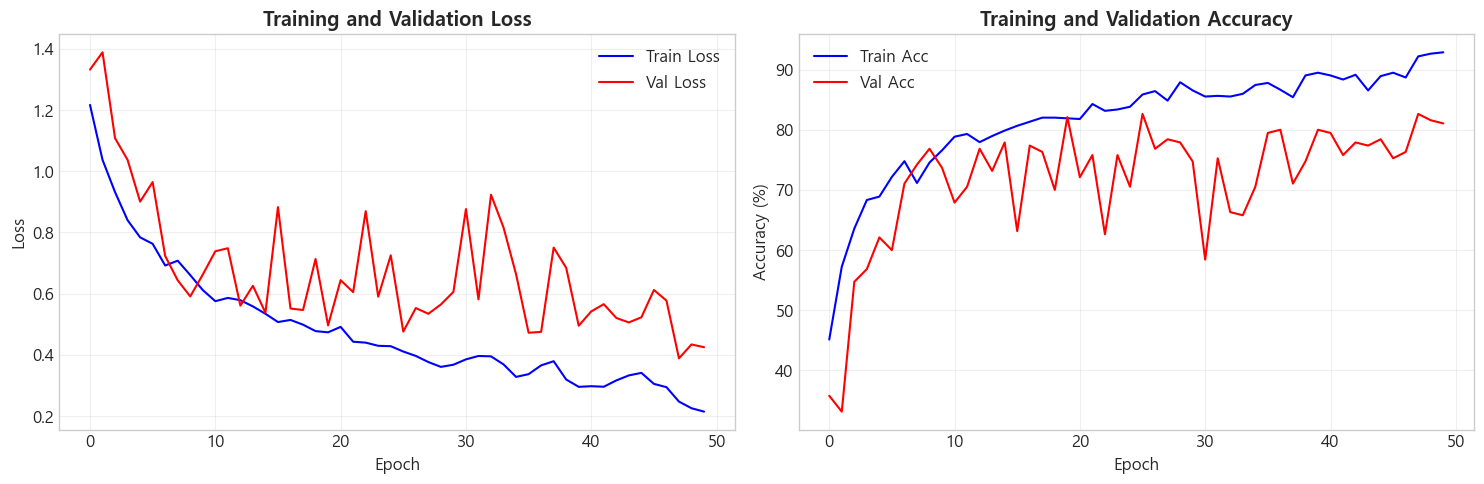

✅ 학습 곡선 시각화 완료!


In [ ]:
# ============================================================
# 학습 곡선 시각화
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(train_losses, label='Train Loss', color='blue')
axes[0].plot(val_losses, label='Val Loss', color='red')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training and Validation Loss', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(train_accs, label='Train Acc', color='blue')
axes[1].plot(val_accs, label='Val Acc', color='red')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Training and Validation Accuracy', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✅ 학습 곡선 시각화 완료!")

---
## 10. 모델 평가


📊 분류 리포트:
                    precision    recall  f1-score   support

           low_oil       0.78      0.81      0.80        48
normal_engine_idle       0.90      0.98      0.94        47
    power_steering       0.84      0.75      0.79        48
   serpentine_belt       0.87      0.85      0.86        47

          accuracy                           0.85       190
         macro avg       0.85      0.85      0.85       190
      weighted avg       0.85      0.85      0.85       190



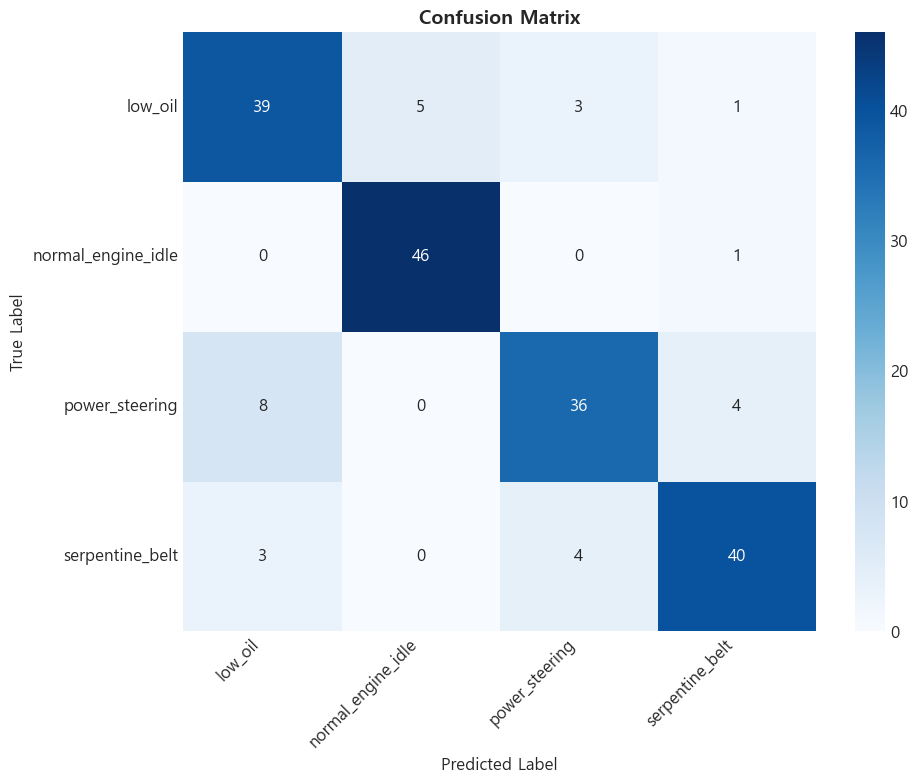


✅ 평가 완료!


In [ ]:
# ============================================================
# 테스트 세트 평가
# ============================================================

ensemble_model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for waveforms, mel_specs, labels in test_loader:
        waveforms = waveforms.to(device)
        mel_specs = mel_specs.to(device)
        labels = labels.to(device)
        
        outputs = ensemble_model(waveforms, mel_specs, mask=importance_mask_tensor)
        _, predicted = torch.max(outputs.data, 1)
        
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# 분류 리포트
target_names = [idx_to_label[i] for i in range(num_classes)]
print("\n📊 분류 리포트:")
print(classification_report(all_labels, all_preds, target_names=target_names))

# 혼동 행렬
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print("\n✅ 평가 완료!")